# AI Ethics Project: Personalized Budget Predictor

Personalization is a central aspect of many core AI systems. In this project, I analyze a hypothetical personalized activity recommender called IDOOU. The system predicts whether a user's activity budget is at least $300 and uses that prediction to tailor recommendations.

**Problem statement:** IDOOU's creators want to know whether users with bachelor's and master's degrees are privileged in terms of receiving the favorable budget label compared with users who graduated from high school. I explore the data, train and compare two classifiers, measure fairness with IBM AIF360, explain the selected model, mitigate bias, and document the final system in a model card.

**Key points:**

- The synthetic data represents a user-experience study of about 300,000 participants.
- Users may choose not to provide requested information, and the missing values in the data reflect that choice.
- A budget prediction is only a planning aid. It must not be treated as a measure of a person's socioeconomic value, creditworthiness, or eligibility for services.


In [1]:
# Dependencies are installed once from requirements.txt into the local .venv.
# This cell verifies that the notebook is running with the expected environment.
import sys
print(f"Python executable: {sys.executable}")
print(f"Python version: {sys.version.split()[0]}")


Python executable: /Users/autobotraos/ai-ethics-budget-predictor/.venv/bin/python
Python version: 3.12.13


**Environment note:** Select the repository's .venv kernel before running the notebook. The tested package versions are pinned in requirements.txt.


In [2]:
# Core analysis imports
from pathlib import Path
from collections import defaultdict
import html
import logging
import warnings

logging.getLogger().setLevel(logging.ERROR)
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from aif360.algorithms.preprocessing import Reweighing
from aif360.datasets import BinaryLabelDataset
from aif360.metrics import BinaryLabelDatasetMetric, ClassificationMetric

from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
)
from sklearn.naive_bayes import GaussianNB

RANDOM_STATE = 42
LABEL_NAME = "Budget (in dollars)_>=300"
PROTECTED_ATTRIBUTE = "Higher_Education"
privileged_groups = [{PROTECTED_ATTRIBUTE: 1.0}]
unprivileged_groups = [{PROTECTED_ATTRIBUTE: 0.0}]

Path("images").mkdir(exist_ok=True)
sns.set_theme(style="whitegrid", context="notebook")


In [3]:
# Load the synthetic IDOOU dataset.
raw_act_rec_dataset = pd.read_csv("udacity_ai_ethics_project_data.csv")
act_rec_dataset = raw_act_rec_dataset.copy()

print(f"Raw dataset shape: {act_rec_dataset.shape}")
display(act_rec_dataset.head())


Raw dataset shape: (300000, 6)


,Budget (in dollars),Age,Gender,Education_Level,With children?,Recommended_Activity
0,3258.0,29.0,Transgender,Bachelor’s Degree,0.0,Stay in: Watch calming TV
1,1741.0,89.0,Other,Bachelor’s Degree,NaN,Play: Visit a movie theater
2,140.0,22.0,NaN,Other,0.0,Play: Visit a movie theater
3,179.0,23.0,Non-binary,Other,0.0,Play: Visit a movie theater
4,3479.0,79.0,Non-binary,Master’s Degree,1.0,Learn: Visit a library


## Step 1: Data Pre-Processing and Evaluation

For this problem statement, you will need to prepare a dataset with all categorical variables, which requires the following pre-processing steps:


- Remove the NA values from the dataset
- Convert Age and Budget (in dollars) to categorical columns with the following binning:

> Bins for Age: 18-24, 25-44, 45-65, 66-92

> Bins for Budget: >=300, <300

In [4]:
# Remove rows with missing values, then bin Age and Budget as required.
original_row_count = len(act_rec_dataset)
missing_by_column = act_rec_dataset.isna().sum().sort_values(ascending=False)

act_rec_dataset = act_rec_dataset.dropna().copy()
act_rec_dataset["Age"] = pd.cut(
    act_rec_dataset["Age"],
    bins=[17, 24, 44, 65, 92],
    labels=["18-24", "25-44", "45-65", "66-92"],
    include_lowest=True,
)
act_rec_dataset["Budget (in dollars)"] = np.where(
    act_rec_dataset["Budget (in dollars)"] >= 300,
    ">=300",
    "<300",
)

print(f"Rows before preprocessing: {original_row_count:,}")
print(f"Rows after dropping missing values: {len(act_rec_dataset):,}")
print(f"Rows removed: {original_row_count - len(act_rec_dataset):,}")
display(missing_by_column.to_frame("Missing values"))
display(act_rec_dataset.head())


Rows before preprocessing: 300,000
Rows after dropping missing values: 156,317
Rows removed: 143,683


,Missing values
With children?,83849
Gender,49799
Education_Level,43592
Budget (in dollars),0
Age,0
Recommended_Activity,0


,Budget (in dollars),Age,Gender,Education_Level,With children?,Recommended_Activity
0,>=300,25-44,Transgender,Bachelor’s Degree,0.0,Stay in: Watch calming TV
3,<300,18-24,Non-binary,Other,0.0,Play: Visit a movie theater
4,>=300,66-92,Non-binary,Master’s Degree,1.0,Learn: Visit a library
5,>=300,25-44,Male,Bachelor’s Degree,1.0,Play: Go shopping
6,>=300,25-44,Non-binary,Master’s Degree,0.0,Explore: Go sightseeing


### Evaluate bias issues in the dataset

Next, let's take a look at potential hints of data bias in the variables, particularly the "Gender", "Age", and "Education" variables.

Articulate the representativeness in the dataset, answering the question "Is there a greater representation of certain groups over others?"

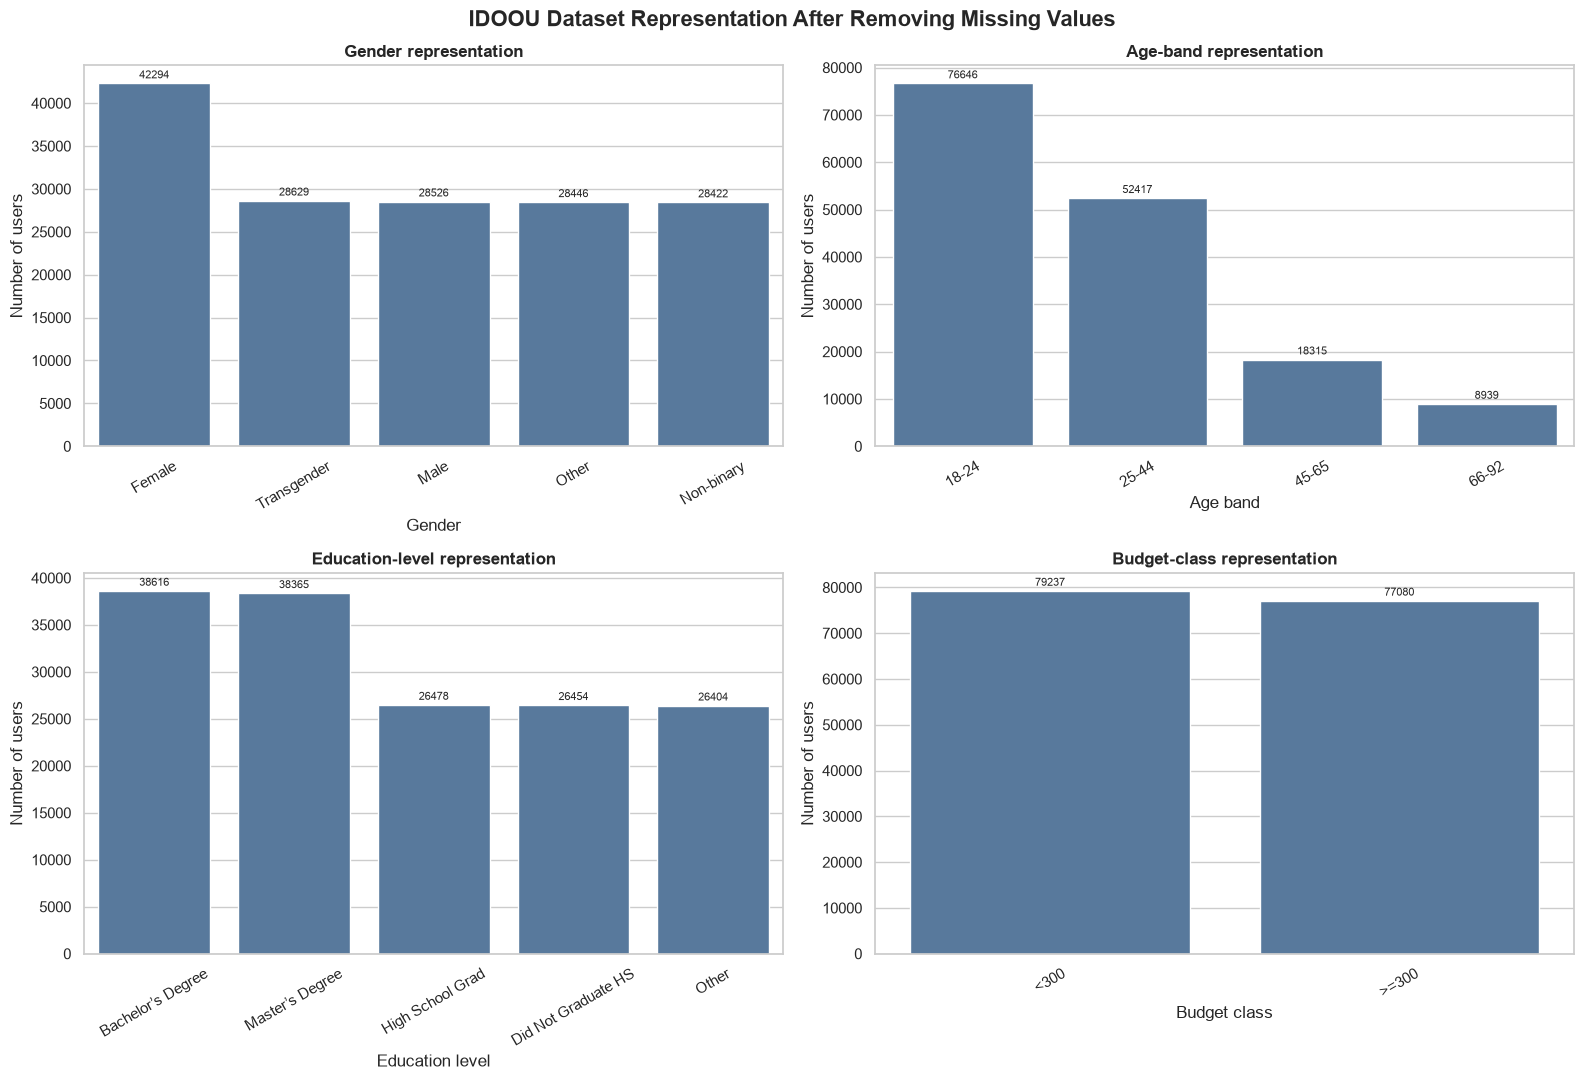

{'Gender': Gender
 Transgender    28629
 Non-binary     28422
 Male           28526
 Other          28446
 Female         42294
 Name: count, dtype: int64,
 'Age': Age
 18-24    76646
 25-44    52417
 45-65    18315
 66-92     8939
 Name: count, dtype: int64,
 'Education_Level': Education_Level
 Bachelor’s Degree      38616
 Other                  26404
 Master’s Degree        38365
 High School Grad       26478
 Did Not Graduate HS    26454
 Name: count, dtype: int64,
 'Budget (in dollars)': Budget (in dollars)
 >=300    77080
 <300     79237
 Name: count, dtype: int64}

In [5]:
# Bar plots show the representation of key categorical groups and target classes.
plot_specs = [
    ("Gender", "Gender representation", "Gender"),
    ("Age", "Age-band representation", "Age band"),
    ("Education_Level", "Education-level representation", "Education level"),
    ("Budget (in dollars)", "Budget-class representation", "Budget class"),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
for ax, (column, title, x_label) in zip(axes.flat, plot_specs):
    counts = act_rec_dataset[column].value_counts()
    if column == "Age":
        counts = act_rec_dataset[column].value_counts(sort=False)
    sns.barplot(x=counts.index.astype(str), y=counts.values, ax=ax, color="#4C78A8")
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel(x_label)
    ax.set_ylabel("Number of users")
    ax.tick_params(axis="x", rotation=30)
    for container in ax.containers:
        ax.bar_label(container, fmt="%.0f", padding=2, fontsize=8)

fig.suptitle("IDOOU Dataset Representation After Removing Missing Values", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("images/eda_group_representation.png", dpi=160, bbox_inches="tight")
plt.show()
plt.close()

representation_summary = {
    column: act_rec_dataset[column].value_counts(sort=False)
    for column, _, _ in plot_specs
}
representation_summary


Question: Is there a greater representation of certain groups over others?

**Your answer:** Yes. After removing incomplete rows, the sample is much younger than the full adult population: the 18–24 band contains 76,646 users, while the 66–92 band contains only 8,939. Female users are also more represented than each other individual gender category, and bachelor's/master's degree holders are more common than the other individual education groups. The two budget classes are comparatively balanced at this stage.

Removing 143,683 rows with missing values may create selection bias because users who withheld information are excluded rather than represented in the model. The uneven age and education distributions also create sample bias and limit how confidently results can be generalized to older adults or users with missing data.


Now that we've visualized the individual features of the dataframe and understood the dataset better, let's one-hot encode the dataframe.

In [6]:
# One-hot encode all categorical fields while retaining numeric binary fields.
act_rec_dataset = pd.get_dummies(act_rec_dataset, dtype=int)

print(f"One-hot encoded shape: {act_rec_dataset.shape}")
display(act_rec_dataset.head())


One-hot encoded shape: (156317, 26)


,With children?,Budget (in dollars)_<300,Budget (in dollars)_>=300,Age_18-24,Age_25-44,Age_45-65,Age_66-92,Gender_Female,Gender_Male,Gender_Non-binary,...,Education_Level_Other,Recommended_Activity_Explore: Go sightseeing,Recommended_Activity_Explore: Hike,Recommended_Activity_Explore: Visit a park,Recommended_Activity_Learn: Visit a library,Recommended_Activity_Play: Go shopping,Recommended_Activity_Play: Visit a movie theater,Recommended_Activity_Stay in: Color,Recommended_Activity_Stay in: Play a game,Recommended_Activity_Stay in: Watch calming TV
0,0.0,0,1,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,0.0,1,0,1,0,0,0,0,0,1,...,1,0,0,0,0,0,1,0,0,0
4,1.0,0,1,0,0,0,1,0,0,1,...,0,0,0,0,1,0,0,0,0,0
5,1.0,0,1,0,1,0,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0
6,0.0,0,1,0,1,0,0,0,0,1,...,0,1,0,0,0,0,0,0,0,0


Visualize the interactions between the categorical variables. Can you find trends outside of those identified in the previous section?

**Hint**: Use a multicollinearity matrix.

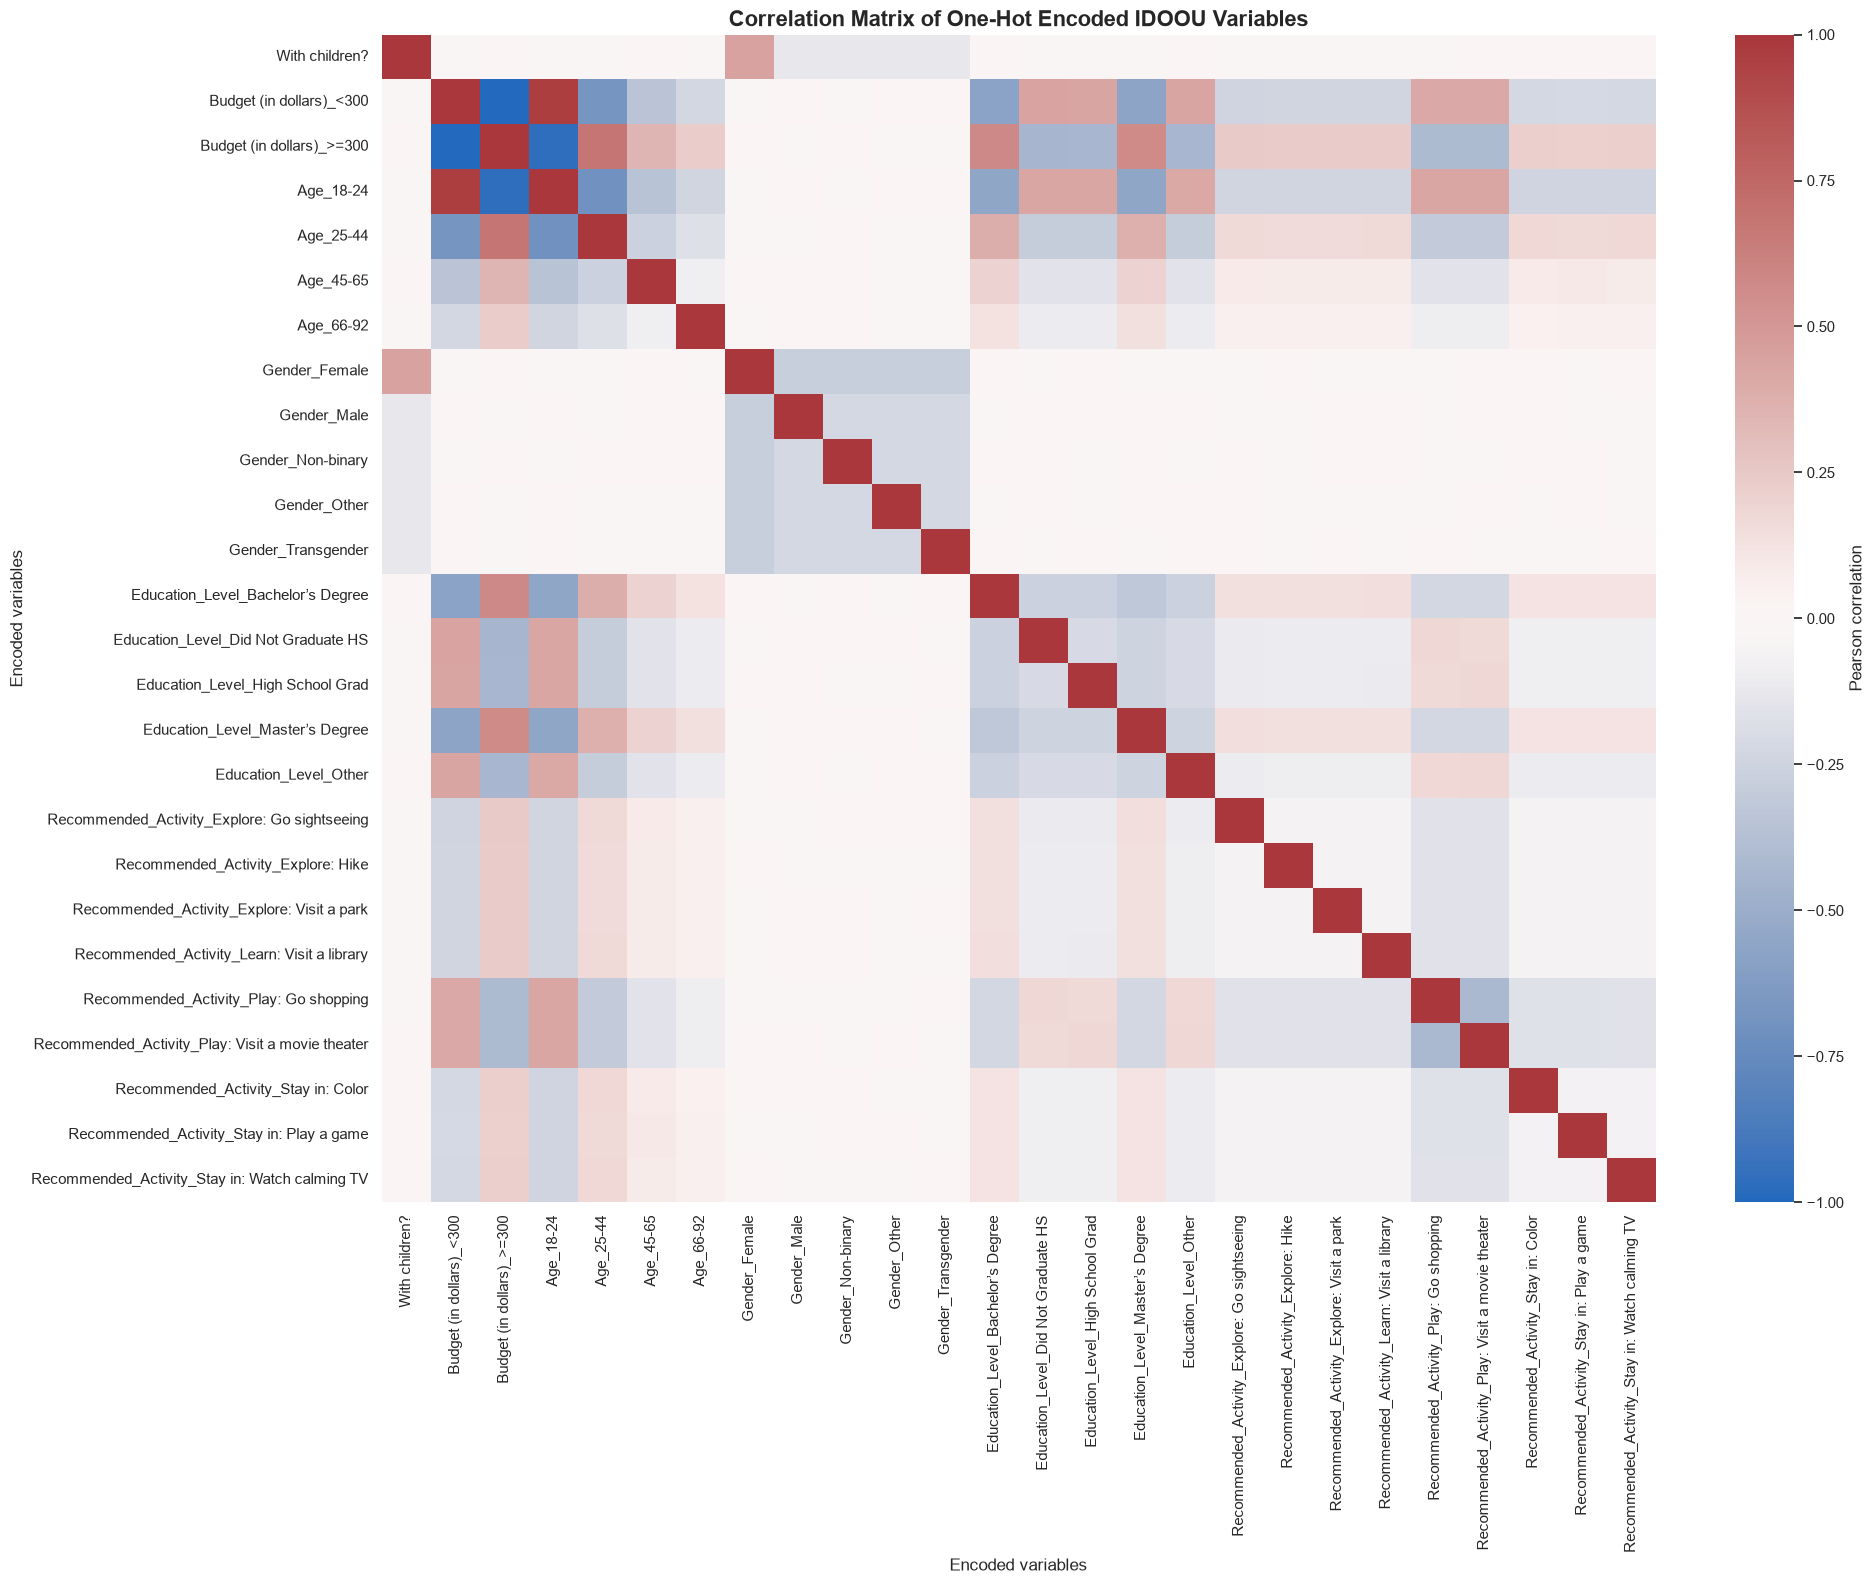

,Correlation with favorable budget
Budget (in dollars)_<300,-1.000000
Age_18-24,-0.967390
Age_25-44,0.673611
Education_Level_Bachelor’s Degree,0.572172
Education_Level_Master’s Degree,0.569736
Education_Level_Did Not Graduate HS,-0.437578
Education_Level_High School Grad,-0.437448
Education_Level_Other,-0.437168
Recommended_Activity_Play: Visit a movie theater,-0.409413
Recommended_Activity_Play: Go shopping,-0.409268


In [7]:
# A correlation matrix reveals relationships and redundant dummy variables.
correlation_matrix = act_rec_dataset.corr(numeric_only=True)

plt.figure(figsize=(20, 16))
sns.heatmap(
    correlation_matrix,
    cmap="vlag",
    center=0,
    vmin=-1,
    vmax=1,
    square=False,
    cbar_kws={"label": "Pearson correlation"},
)
plt.title("Correlation Matrix of One-Hot Encoded IDOOU Variables", fontsize=16, fontweight="bold")
plt.xlabel("Encoded variables")
plt.ylabel("Encoded variables")
plt.tight_layout()
plt.savefig("images/eda_correlation_matrix.png", dpi=160, bbox_inches="tight")
plt.show()
plt.close()

target_correlations = (
    correlation_matrix["Budget (in dollars)_>=300"]
    .drop("Budget (in dollars)_>=300")
    .sort_values(key=np.abs, ascending=False)
    .head(12)
)
display(target_correlations.to_frame("Correlation with favorable budget"))


Question: What trends did you spot in the interactions between the categorical variables?

**Your answer:** The 18–24 age indicator has the strongest non-constructed relationship with the favorable budget class (approximately −0.967). The bachelor's and master's indicators are also strongly positively associated with a budget of at least $300 (approximately 0.57 each), while the high-school indicator is negatively associated (approximately −0.44). Complementary dummy columns, including the two budget classes and mutually exclusive education categories, are strongly negatively correlated by construction; they should not all be retained as independent predictors.

Age and education therefore represent the clearest fairness risks in these interactions. Some recommended-activity indicators have moderate correlations with the target, while gender indicators are comparatively weak. These patterns do not establish causation and should be audited for proxy effects.


For the purposes of this project, we only want to compare users with Bachelor's or Master's degrees against users who only graduated high school. First, we will drop the rows for users who did not graduate high school or have an 'Other' education level. Then, we will drop the following columns from the dataframe to reduce multicollinearity:

- Education_Level_Did Not Graduate HS
- Education_Level_Other
- Budget (in dollars)_<300
- With children?

In [8]:
# Retain the education groups in scope: higher education versus high school.
act_rec_dataset = act_rec_dataset[
    (act_rec_dataset["Education_Level_Did Not Graduate HS"] == 0)
    & (act_rec_dataset["Education_Level_Other"] == 0)
].copy()

# Create a clear binary protected attribute for the fairness analysis.
act_rec_dataset[PROTECTED_ATTRIBUTE] = (
    (act_rec_dataset["Education_Level_Bachelor’s Degree"] == 1)
    | (act_rec_dataset["Education_Level_Master’s Degree"] == 1)
).astype(int)

# Remove out-of-scope/redundant columns identified by the starter notebook.
act_rec_dataset = act_rec_dataset.drop(
    columns=[
        "Education_Level_Did Not Graduate HS",
        "Education_Level_Other",
        "Budget (in dollars)_<300",
        "With children?",
    ]
)

print(f"Modeling dataset shape: {act_rec_dataset.shape}")
display(
    act_rec_dataset.groupby(PROTECTED_ATTRIBUTE)[LABEL_NAME]
    .agg(["count", "mean"])
    .rename(index={0: "High school", 1: "Bachelor's/Master's"})
)
display(act_rec_dataset.head())


Modeling dataset shape: (103459, 23)


,count,mean
Higher_Education,,
High school,26478,0.008800
Bachelor's/Master's,76981,0.992531


,Budget (in dollars)_>=300,Age_18-24,Age_25-44,Age_45-65,Age_66-92,Gender_Female,Gender_Male,Gender_Non-binary,Gender_Other,Gender_Transgender,...,Recommended_Activity_Explore: Go sightseeing,Recommended_Activity_Explore: Hike,Recommended_Activity_Explore: Visit a park,Recommended_Activity_Learn: Visit a library,Recommended_Activity_Play: Go shopping,Recommended_Activity_Play: Visit a movie theater,Recommended_Activity_Stay in: Color,Recommended_Activity_Stay in: Play a game,Recommended_Activity_Stay in: Watch calming TV,Higher_Education
0,1,0,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,1,1
4,1,0,0,0,1,0,0,1,0,0,...,0,0,0,1,0,0,0,0,0,1
5,1,0,1,0,0,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,1
6,1,0,1,0,0,0,0,1,0,0,...,1,0,0,0,0,0,0,0,0,1
8,1,0,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,1,0,0,1


### Evaluate fairness issues

Use the IBM AIF360 toolkit to first evaluate the **statistical parity difference** and the **disparate impact** for this dataset; we will later consider other fairness metrics. Interpret your findings - is there bias in the proposed problem statement? If yes, what group is benefitting?

**Hint**: Use the BinaryLabelDataset and the BinaryLabelDatasetMetric functions for the fairness evaluation. The reported Statistical Parity Difference may be within -0.64 and -0.55, and the Disparate impact value may be within 0.136 and 0.0150.

In [9]:
binary_act_dataset = BinaryLabelDataset(
    df=act_rec_dataset,
    label_names=[LABEL_NAME],
    protected_attribute_names=[PROTECTED_ATTRIBUTE],
    favorable_label=1.0,
    unfavorable_label=0.0,
)

print(binary_act_dataset)


               instance weights  features                                \
                                                                          
                                Age_18-24 Age_25-44 Age_45-65 Age_66-92   
instance names                                                            
0                           1.0       0.0       1.0       0.0       0.0   
4                           1.0       0.0       0.0       0.0       1.0   
5                           1.0       0.0       1.0       0.0       0.0   
6                           1.0       0.0       1.0       0.0       0.0   
8                           1.0       0.0       1.0       0.0       0.0   
...                         ...       ...       ...       ...       ...   
299981                      1.0       0.0       1.0       0.0       0.0   
299983                      1.0       0.0       1.0       0.0       0.0   
299984                      1.0       1.0       0.0       0.0       0.0   
299990                   

In [10]:
orig_metric_act_dataset = BinaryLabelDatasetMetric(
    binary_act_dataset,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups,
)

data_statistical_parity = orig_metric_act_dataset.statistical_parity_difference()
data_disparate_impact = orig_metric_act_dataset.disparate_impact()

print(f"Statistical Parity Difference = {data_statistical_parity:.6f}")
print(f"Disparate Impact = {data_disparate_impact:.6f}")
print("Ideal values: statistical parity difference = 0; disparate impact = 1.")


Statistical Parity Difference = -0.983731
Disparate Impact = 0.008866
Ideal values: statistical parity difference = 0; disparate impact = 1.


Question: Evaluate the fairness metrics. What are your findings? Is there bias in the proposed problem statement? If yes, what group is benefitting?

**Your answer:** The dataset has a statistical parity difference of approximately **−0.984** and a disparate impact of approximately **0.0089**, matching the rubric's expected ranges. The high-school group receives the favorable budget label at less than one percent of the rate of the bachelor's/master's group. Both metrics are extremely far from their ideal values of 0 and 1, respectively.

The privileged group is therefore users with bachelor's or master's degrees. This is severe historical/measurement bias in the synthetic labels, not proof that education legitimately determines a user's budget. Training directly on these labels risks reproducing that inequity.


## Step 2: Investigate an ML model on the problematic Dataset

For this project, we are using a train-test-validation split.

You have available boilerplate for training 2 ML models on this dataset - you will need to train these models and use the methods we covered in this course to identify and evaluate their performance (**using the accuracy metric and confusion matrix**).

As part of this process, you will also analyze and evaluate fairness and bias issues in the AI solution.

In [11]:
# Reproducible 50% training, 30% validation, and 20% test split.
orig_train, orig_validate, orig_test = binary_act_dataset.split(
    [0.5, 0.8],
    shuffle=True,
    seed=RANDOM_STATE,
)

print(f"Training rows: {len(orig_train.labels):,}")
print(f"Validation rows: {len(orig_validate.labels):,}")
print(f"Test rows: {len(orig_test.labels):,}")


Training rows: 51,729
Validation rows: 31,038
Test rows: 20,692


In [12]:
def prediction_dataset(dataset, model, threshold):
    probabilities = model.predict_proba(dataset.features)
    positive_index = np.where(model.classes_ == dataset.favorable_label)[0][0]

    predicted = dataset.copy(deepcopy=True)
    predicted.scores = probabilities[:, positive_index].reshape(-1, 1)
    predicted.labels = (predicted.scores >= threshold).astype(np.float64)
    return predicted


def classification_metrics(true_dataset, predicted_dataset):
    metric = ClassificationMetric(
        true_dataset,
        predicted_dataset,
        unprivileged_groups=unprivileged_groups,
        privileged_groups=privileged_groups,
    )
    return {
        "accuracy": metric.accuracy(),
        "balanced_accuracy": 0.5
        * (metric.true_positive_rate() + metric.true_negative_rate()),
        "average_odds_difference": metric.average_odds_difference(),
        "statistical_parity_difference": metric.statistical_parity_difference(),
        "equal_opportunity_difference": metric.equal_opportunity_difference(),
        "disparate_impact": metric.disparate_impact(),
        "theil_index": metric.theil_index(),
        "true_positive_rate": metric.true_positive_rate(),
        "true_negative_rate": metric.true_negative_rate(),
        "false_positives": metric.num_false_positives(),
        "false_negatives": metric.num_false_negatives(),
    }


def evaluate_thresholds(dataset, model, threshold_array):
    metric_arrays = defaultdict(list)
    for threshold in threshold_array:
        predicted = prediction_dataset(dataset, model, threshold)
        result = classification_metrics(dataset, predicted)
        for name, value in result.items():
            metric_arrays[name].append(value)
    return metric_arrays


def describe_metrics(metrics, threshold_array):
    best_index = int(np.argmax(metrics["balanced_accuracy"]))
    print(f"Selected threshold: {threshold_array[best_index]:.4f}")
    print(f"Balanced accuracy: {metrics['balanced_accuracy'][best_index]:.4f}")
    print(f"Average odds difference: {metrics['average_odds_difference'][best_index]:.4f}")
    print(f"Statistical parity difference: {metrics['statistical_parity_difference'][best_index]:.4f}")
    print(f"Equal opportunity difference: {metrics['equal_opportunity_difference'][best_index]:.4f}")
    print(f"Theil index: {metrics['theil_index'][best_index]:.4f}")
    return best_index


def print_metric_report(title, result):
    print(f"\n{title}")
    for name, value in result.items():
        print(f"{name.replace('_', ' ').title()}: {value:.4f}")


In [13]:
thresh_arr = np.linspace(0.01, 0.99, 99)

GNB_model = GaussianNB().fit(
    orig_train.features,
    orig_train.labels.ravel(),
    sample_weight=orig_train.instance_weights,
)

gnb_validation_metrics = evaluate_thresholds(orig_validate, GNB_model, thresh_arr)
gnb_best_index = describe_metrics(gnb_validation_metrics, thresh_arr)
gnb_threshold = thresh_arr[gnb_best_index]
gnb_test_prediction = prediction_dataset(orig_test, GNB_model, gnb_threshold)
gnb_test_metrics = classification_metrics(orig_test, gnb_test_prediction)
print_metric_report("Gaussian Naive Bayes test metrics", gnb_test_metrics)


Selected threshold: 0.0100
Balanced accuracy: 0.9982
Average odds difference: -0.5115
Statistical parity difference: -0.9926
Equal opportunity difference: -1.0000
Theil index: 0.0024

Gaussian Naive Bayes test metrics
Accuracy: 0.9976
Balanced Accuracy: 0.9980
Average Odds Difference: -0.5278
Statistical Parity Difference: -0.9934
Equal Opportunity Difference: -1.0000
Disparate Impact: 0.0000
Theil Index: 0.0022
True Positive Rate: 0.9972
True Negative Rate: 0.9989
False Positives: 6.0000
False Negatives: 43.0000


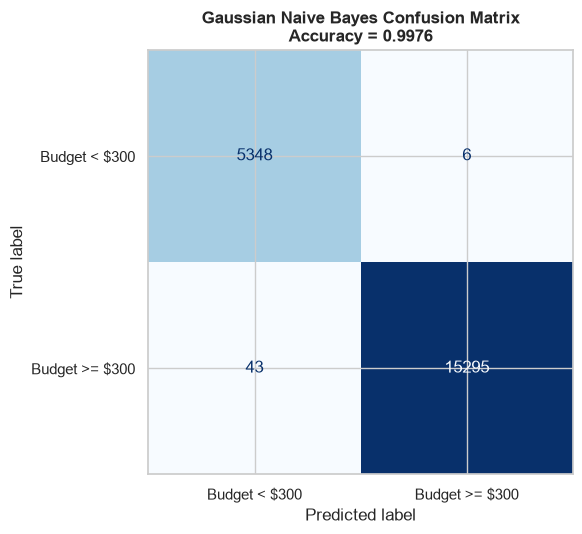

In [14]:
gnb_accuracy = accuracy_score(
    orig_test.labels.ravel(),
    gnb_test_prediction.labels.ravel(),
)
gnb_confusion = confusion_matrix(
    orig_test.labels.ravel(),
    gnb_test_prediction.labels.ravel(),
)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
ConfusionMatrixDisplay(
    confusion_matrix=gnb_confusion,
    display_labels=["Budget < $300", "Budget >= $300"],
).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"Gaussian Naive Bayes Confusion Matrix\nAccuracy = {gnb_accuracy:.4f}", fontweight="bold")
plt.tight_layout()
plt.savefig("images/gnb_confusion_matrix.png", dpi=160, bbox_inches="tight")
plt.show()
plt.close()


In [15]:
LR_model = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE,
).fit(
    orig_train.features,
    orig_train.labels.ravel(),
    sample_weight=orig_train.instance_weights,
)


In [16]:
lr_validation_metrics = evaluate_thresholds(orig_validate, LR_model, thresh_arr)
lr_best_index = describe_metrics(lr_validation_metrics, thresh_arr)
lr_threshold = thresh_arr[lr_best_index]
lr_test_prediction = prediction_dataset(orig_test, LR_model, lr_threshold)
lr_test_metrics = classification_metrics(orig_test, lr_test_prediction)
print_metric_report("Logistic Regression test metrics", lr_test_metrics)


Selected threshold: 0.3100
Balanced accuracy: 0.9982
Average odds difference: -0.5115
Statistical parity difference: -0.9926
Equal opportunity difference: -1.0000
Theil index: 0.0024

Logistic Regression test metrics
Accuracy: 0.9976
Balanced Accuracy: 0.9980
Average Odds Difference: -0.5278
Statistical Parity Difference: -0.9934
Equal Opportunity Difference: -1.0000
Disparate Impact: 0.0000
Theil Index: 0.0022
True Positive Rate: 0.9972
True Negative Rate: 0.9989
False Positives: 6.0000
False Negatives: 43.0000


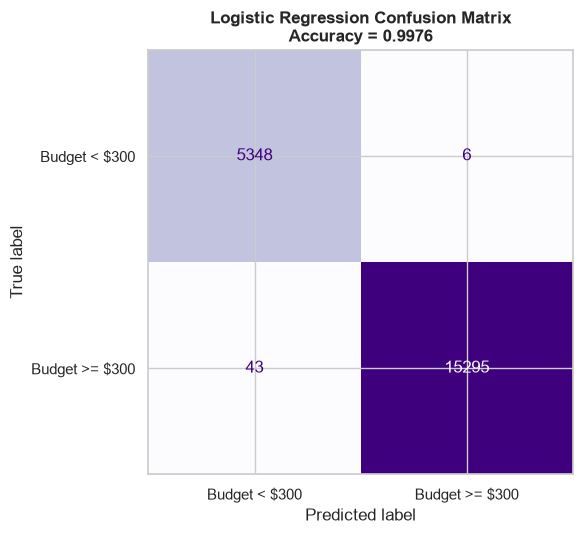

In [17]:
lr_accuracy = accuracy_score(
    orig_test.labels.ravel(),
    lr_test_prediction.labels.ravel(),
)
lr_confusion = confusion_matrix(
    orig_test.labels.ravel(),
    lr_test_prediction.labels.ravel(),
)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
ConfusionMatrixDisplay(
    confusion_matrix=lr_confusion,
    display_labels=["Budget < $300", "Budget >= $300"],
).plot(ax=ax, cmap="Purples", colorbar=False)
ax.set_title(f"Logistic Regression Confusion Matrix\nAccuracy = {lr_accuracy:.4f}", fontweight="bold")
plt.tight_layout()
plt.savefig("images/lr_confusion_matrix.png", dpi=160, bbox_inches="tight")
plt.show()
plt.close()


,Model,Accuracy,Balanced accuracy
0,Gaussian Naive Bayes,0.9976,0.9980
1,Logistic Regression,0.9976,0.9980


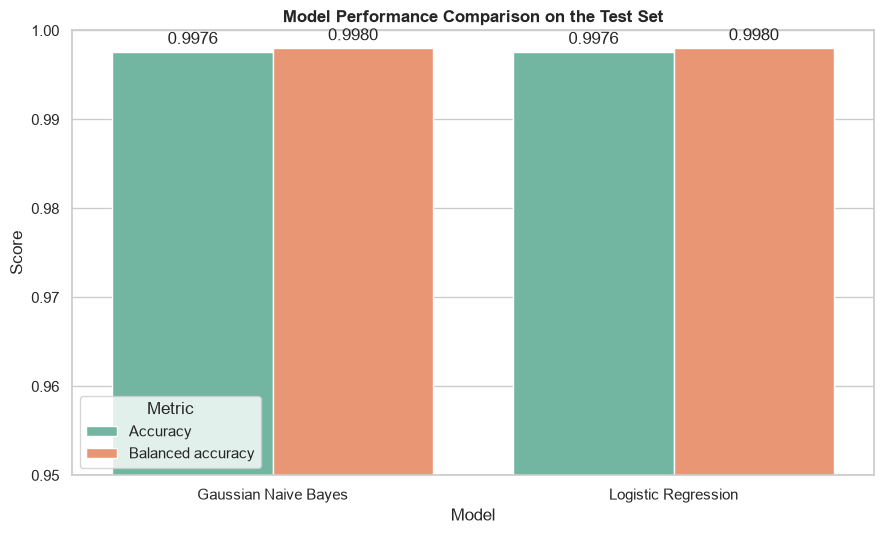

In [18]:
model_accuracy = pd.DataFrame(
    {
        "Model": ["Gaussian Naive Bayes", "Logistic Regression"],
        "Accuracy": [gnb_test_metrics["accuracy"], lr_test_metrics["accuracy"]],
        "Balanced accuracy": [
            gnb_test_metrics["balanced_accuracy"],
            lr_test_metrics["balanced_accuracy"],
        ],
    }
)
display(model_accuracy.style.format({"Accuracy": "{:.4f}", "Balanced accuracy": "{:.4f}"}))

comparison_long = model_accuracy.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score",
)
plt.figure(figsize=(9, 5.5))
ax = sns.barplot(data=comparison_long, x="Model", y="Score", hue="Metric", palette="Set2")
ax.set_ylim(0.95, 1.0)
ax.set_title("Model Performance Comparison on the Test Set", fontweight="bold")
ax.set_xlabel("Model")
ax.set_ylabel("Score")
for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=3)
plt.tight_layout()
plt.savefig("images/model_accuracy_comparison.png", dpi=160, bbox_inches="tight")
plt.show()
plt.close()


,Metric,Gaussian Naive Bayes,Logistic Regression
0,Average odds difference,-0.5278,-0.5278
1,Statistical parity difference,-0.9934,-0.9934
2,Equal opportunity difference,-1.0000,-1.0000
3,Theil index,0.0022,0.0022


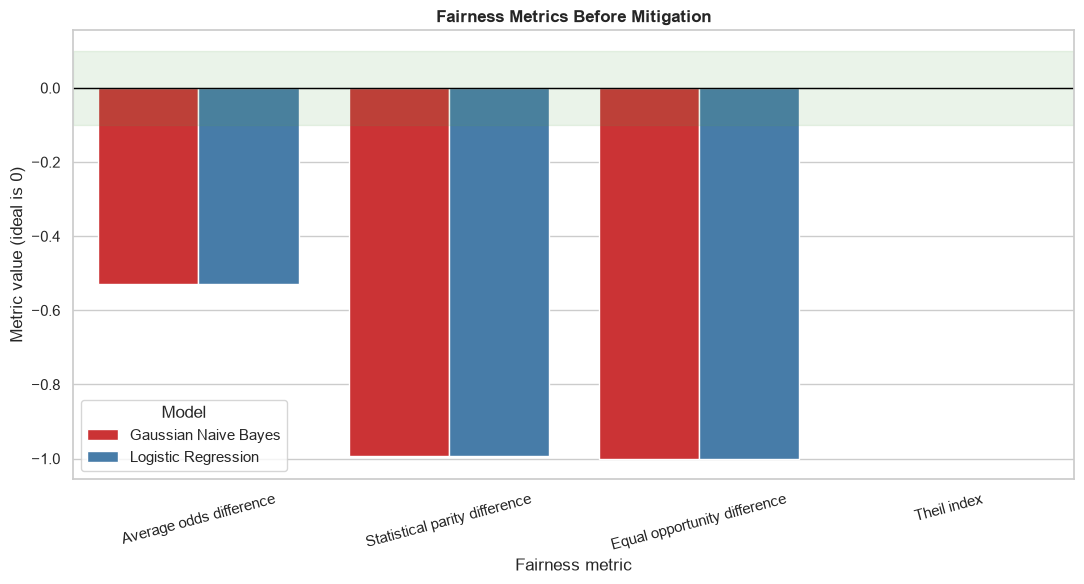

In [19]:
fairness_columns = {
    "Average odds difference": "average_odds_difference",
    "Statistical parity difference": "statistical_parity_difference",
    "Equal opportunity difference": "equal_opportunity_difference",
    "Theil index": "theil_index",
}
fairness_comparison = pd.DataFrame(
    {
        "Metric": list(fairness_columns),
        "Gaussian Naive Bayes": [
            gnb_test_metrics[key] for key in fairness_columns.values()
        ],
        "Logistic Regression": [
            lr_test_metrics[key] for key in fairness_columns.values()
        ],
    }
)
display(fairness_comparison.style.format(precision=4))

fairness_long = fairness_comparison.melt(
    id_vars="Metric",
    var_name="Model",
    value_name="Value",
)
plt.figure(figsize=(11, 6))
ax = sns.barplot(data=fairness_long, x="Metric", y="Value", hue="Model", palette="Set1")
ax.axhline(0, color="black", linewidth=1)
ax.axhspan(-0.1, 0.1, color="#59A14F", alpha=0.12, label="Typical ±0.1 fairness band")
ax.set_title("Fairness Metrics Before Mitigation", fontweight="bold")
ax.set_xlabel("Fairness metric")
ax.set_ylabel("Metric value (ideal is 0)")
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.savefig("images/model_fairness_comparison.png", dpi=160, bbox_inches="tight")
plt.show()
plt.close()


Question: Interpret and compare the results of each model. What do you find in the false negative and false positive of each model? What about the fairness metrics?

**Your answer:** Both models achieve approximately 99.8% accuracy and balanced accuracy on the test set because education almost determines the synthetic label. Each model produces only a handful of false positives and several dozen false negatives, so their aggregate performance is nearly identical.

High predictive performance does not mean the models are fair. Both models have an average odds difference near −0.53, a statistical parity difference near −0.99, and an equal opportunity difference of −1.00. The high-school group therefore receives far fewer favorable predictions and has a much lower true-positive rate. The Theil index is close to zero, illustrating why several fairness metrics are required: a low individual inequality score does not cancel the severe between-group disparity.


Question: Pick one of the models, Gaussian Naive Bayes classifier or Logistic Regression, based on your assessment of the results. Briefly explain your reason.

**Your answer:** I selected Logistic Regression. Its predictive and fairness results are effectively tied with Gaussian Naive Bayes, but Logistic Regression is easier to explain, supports probability-based threshold selection, works naturally with AIF360 instance weights, and is straightforward to audit with permutation importance. The selection is not an endorsement of the unmitigated model; it is the most practical base model for the mitigation and transparency workflow.


## Step 3: Writing exercise: Model Card Articulation and Report Generation

Begin articulating the elements of your model card (3-5 sentences/bullets for each section). Please delineate bullet points using two hyphens, as show in the example below.

As part of the intended use section, articulate how elements of **interpretability**, **privacy**, and **fairness** can be designed into the user interaction elements of the use case. **Hint:** Should IDOOU prompt the user to check whether the budget predictor model's results are correct?

In [20]:
model_details = """
-- The IDOOU Budget Predictor is a binary Logistic Regression model that estimates whether a user's activity budget is at least $300.
-- The model is developed with Python, scikit-learn, and IBM AIF360 on a synthetic user-experience dataset.
-- A reproducible 50/30/20 training, validation, and test split with random seed 42 is used.
-- The final pipeline applies AIF360 Reweighing to the training data and chooses its classification threshold on the validation set.
"""

intended_use = """
-- IDOOU may use the prediction as an optional planning signal when suggesting activities whose likely costs align with a user's stated preferences.
-- The model is not intended for credit, insurance, employment, housing, pricing, eligibility, or any decision that affects access to essential services.
-- The app should ask users to confirm or correct the estimated budget, allow them to skip demographic questions, and let them enter a budget directly.
-- The interface should show a plain-language explanation of the strongest contributing factors and state that the estimate is uncertain.
-- Users should be able to inspect, correct, or remove input features, and the direct user-provided budget must override the model.
"""

factors = """
-- The target is a binary indicator of whether the activity budget is at least $300.
-- Model features are categorical age bands, gender, education level, recommended activity, and a higher-education protected attribute after one-hot encoding.
-- Education is treated as the protected comparison: bachelor's/master's degree users are privileged and high-school graduates are unprivileged for this analysis.
-- Missing gender, education, or parental-status rows are excluded by the required preprocessing, which may create selection bias.
"""


Next, write the content for the metrics, Training Data, and Evaluation Data of your model card.

In [21]:
metrics = """
-- Accuracy and balanced accuracy measure aggregate predictive performance, while confusion matrices expose false positives and false negatives. Balanced accuracy has an ideal value of 1.0, and the recommended range for this project is 0.85 to 1.0.
-- Statistical parity difference has an ideal value of 0, and disparate impact has an ideal value of 1.
-- Average odds difference and equal opportunity difference have ideal values of 0; values within ±0.10 are treated as a practical fairness threshold in this project.
-- The Theil index has an ideal value of 0, with lower nonnegative values indicating less individual inequality.
-- Permutation importance explains how much each input contributes to balanced accuracy, and education-level cohort plots test performance consistency.
"""

training_data = """
-- The raw synthetic dataset contains 300,000 rows and six columns.
-- Required complete-case preprocessing leaves 156,317 rows, and restricting the comparison to bachelor's, master's, and high-school users leaves 103,459 rows.
-- The training split contains 51,729 rows and is the only split transformed by AIF360 Reweighing.
"""

eval_data = """
-- The validation split contains 31,038 rows and is used only to select the classification threshold.
-- The held-out test split contains 20,692 rows and is used once for the final performance, fairness, confusion-matrix, interpretability, and cohort reports.
-- All splits are produced with random seed 42 for reproducibility.
"""


## Step 4: Use Interpretability mechanisms

Use an interpretability mechanism(s) of your choice, e.g. permutation importance, LIME, etc., to understand the feature importance and model's predictions on the test dataset. **Visualize** and note down the key contributing factors - you will later incorporate this in your model card.

,Feature,Importance,Std
0,Age_18-24,0.042837,0.000647
10,Education_Level_High School Grad,0.011041,0.000418
21,Higher_Education,0.011041,0.000418
11,Education_Level_Master’s Degree,0.005369,0.000486
9,Education_Level_Bachelor’s Degree,0.005276,0.000619
1,Age_25-44,0.002445,0.000147
2,Age_45-65,0.001892,0.000223
3,Age_66-92,0.001129,0.000512
8,Gender_Transgender,0.000000,0.000000
7,Gender_Other,0.000000,0.000000


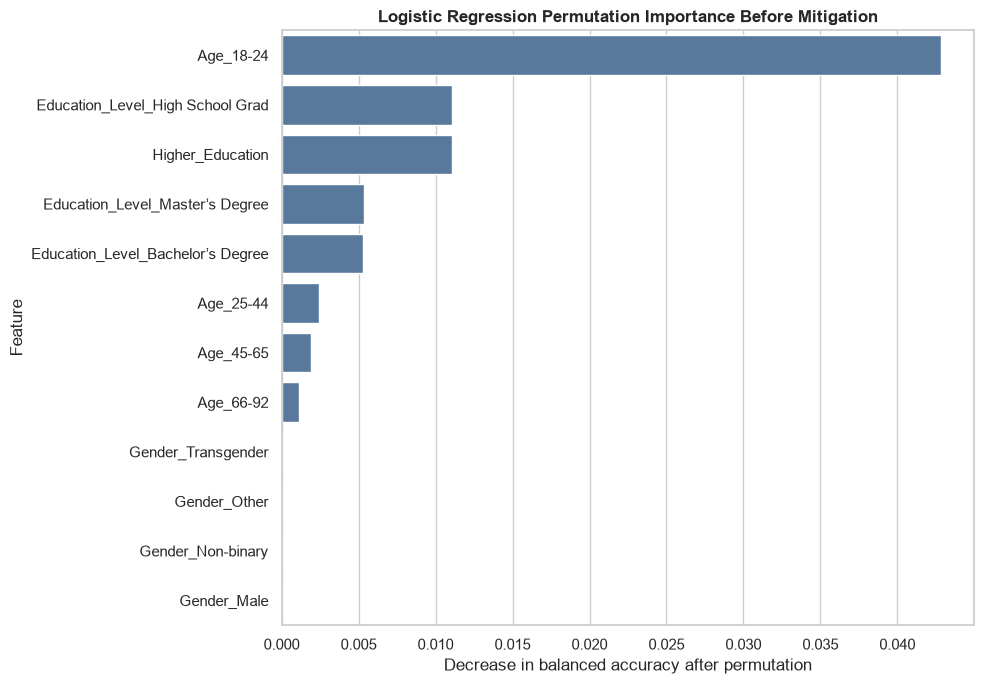

In [22]:
# Model-agnostic permutation importance on the selected unmitigated model.
baseline_importance = permutation_importance(
    LR_model,
    orig_test.features,
    orig_test.labels.ravel(),
    scoring="balanced_accuracy",
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=1,
)
baseline_feature_importance = (
    pd.DataFrame(
        {
            "Feature": orig_test.feature_names,
            "Importance": baseline_importance.importances_mean,
            "Std": baseline_importance.importances_std,
        }
    )
    .sort_values("Importance", ascending=False)
    .head(12)
)
display(baseline_feature_importance)

plt.figure(figsize=(10, 7))
ax = sns.barplot(
    data=baseline_feature_importance,
    x="Importance",
    y="Feature",
    color="#4C78A8",
)
ax.set_title("Logistic Regression Permutation Importance Before Mitigation", fontweight="bold")
ax.set_xlabel("Decrease in balanced accuracy after permutation")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.savefig("images/lr_permutation_importance.png", dpi=160, bbox_inches="tight")
plt.show()
plt.close()


Question: Which interpretability mechanism did you choose? What are the key contributing factors?

**Your answer:** I used permutation importance because it is model-agnostic, directly measures the change in held-out balanced accuracy, and is easy to explain to nontechnical stakeholders. The 18–24 age indicator is the strongest individual feature in the unmitigated model. The higher-education, high-school, bachelor's, and master's indicators are the next major contributors, while gender and activity indicators contribute almost nothing.

This finding is ethically important: the model's excellent accuracy relies on age and education patterns rather than neutral evidence about a user's actual spending preference. After Reweighing, the education features lose most of their measured importance and the 18–24 indicator becomes even more dominant, showing that mitigation can shift dependence toward another sensitive or correlated factor. Age therefore requires its own cohort audit and monitoring.


## Step 5: Apply a bias mitigation strategy

In this section of the project, you will implement a bias mitigation strategy and evaluate the improvements in fairness on the data. Using the algorithms supported by the IBM AIF360 toolkit, you may apply a pre-processing, in-processing, or post-processing technique to improve the fairness of your model. Optionally, you may also consider combining multiple techniques.

**Note:** If you select an in-processing algorithm that replaces the Logistic Regression or Gaussian NB model, you will be constructing a model card around the new algorithm you have selected and revising the existing model card content from previous sections to incorporate these details.

In [23]:
# Pre-processing mitigation: reweight the four protected-group/label combinations.
# The transformation changes training instance weights, not labels or test data.
reweigher = Reweighing(
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups,
)
reweighed_train = reweigher.fit_transform(orig_train)

LR_mitigated_model = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE,
).fit(
    reweighed_train.features,
    reweighed_train.labels.ravel(),
    sample_weight=reweighed_train.instance_weights,
)

mitigated_validation_metrics = evaluate_thresholds(
    orig_validate,
    LR_mitigated_model,
    thresh_arr,
)
mitigated_best_index = describe_metrics(mitigated_validation_metrics, thresh_arr)
mitigated_threshold = thresh_arr[mitigated_best_index]


Selected threshold: 0.0100
Balanced accuracy: 0.9827
Average odds difference: 0.0059
Statistical parity difference: -0.9492
Equal opportunity difference: 0.0000
Theil index: 0.0034



Mitigated Logistic Regression test metrics
Accuracy: 0.9913
Balanced Accuracy: 0.9831
Average Odds Difference: -0.0111
Statistical Parity Difference: -0.9522
Equal Opportunity Difference: 0.0000
Disparate Impact: 0.0415
Theil Index: 0.0033
True Positive Rate: 1.0000
True Negative Rate: 0.9662
False Positives: 181.0000
False Negatives: 0.0000


,Metric,Before mitigation,After mitigation
0,Accuracy,0.9976,0.9913
1,Balanced accuracy,0.9980,0.9831
2,Average odds difference,-0.5278,-0.0111
3,Statistical parity difference,-0.9934,-0.9522
4,Equal opportunity difference,-1.0000,0.0000
5,Theil index,0.0022,0.0033


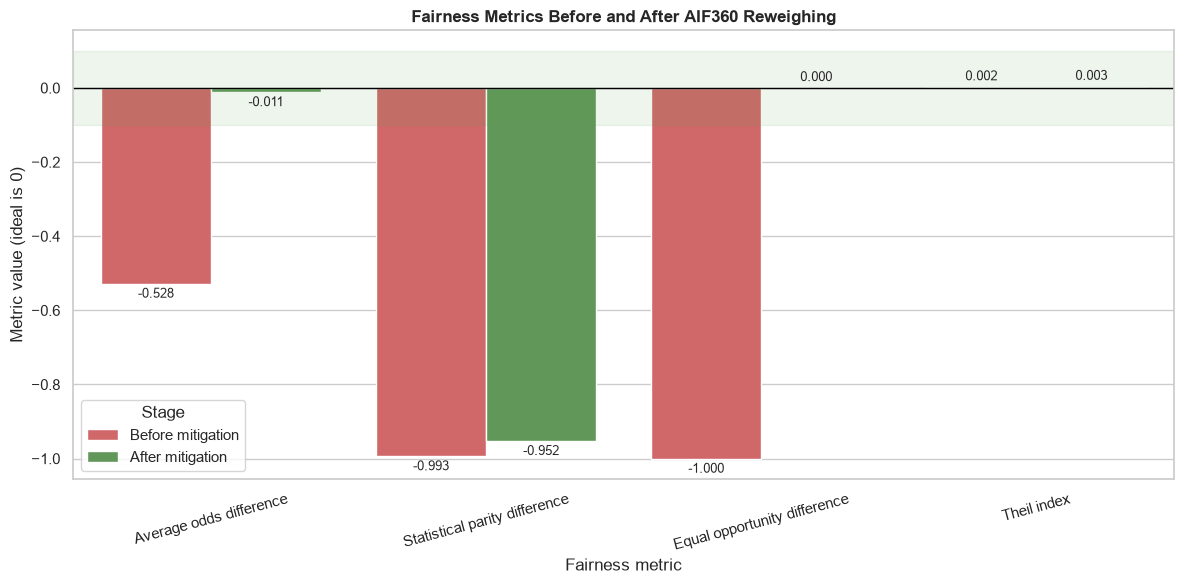

In [24]:
mitigated_test_prediction = prediction_dataset(
    orig_test,
    LR_mitigated_model,
    mitigated_threshold,
)
mitigated_test_metrics = classification_metrics(
    orig_test,
    mitigated_test_prediction,
)
print_metric_report("Mitigated Logistic Regression test metrics", mitigated_test_metrics)

before_after_metrics = pd.DataFrame(
    {
        "Metric": [
            "Accuracy",
            "Balanced accuracy",
            "Average odds difference",
            "Statistical parity difference",
            "Equal opportunity difference",
            "Theil index",
        ],
        "Before mitigation": [
            lr_test_metrics["accuracy"],
            lr_test_metrics["balanced_accuracy"],
            lr_test_metrics["average_odds_difference"],
            lr_test_metrics["statistical_parity_difference"],
            lr_test_metrics["equal_opportunity_difference"],
            lr_test_metrics["theil_index"],
        ],
        "After mitigation": [
            mitigated_test_metrics["accuracy"],
            mitigated_test_metrics["balanced_accuracy"],
            mitigated_test_metrics["average_odds_difference"],
            mitigated_test_metrics["statistical_parity_difference"],
            mitigated_test_metrics["equal_opportunity_difference"],
            mitigated_test_metrics["theil_index"],
        ],
    }
)
display(before_after_metrics.style.format(precision=4))

fairness_plot_data = before_after_metrics[
    before_after_metrics["Metric"].isin(
        [
            "Average odds difference",
            "Statistical parity difference",
            "Equal opportunity difference",
            "Theil index",
        ]
    )
].melt(id_vars="Metric", var_name="Stage", value_name="Value")

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=fairness_plot_data, x="Metric", y="Value", hue="Stage", palette=["#E15759", "#59A14F"])
ax.axhline(0, color="black", linewidth=1)
ax.axhspan(-0.1, 0.1, color="#59A14F", alpha=0.10)
ax.set_title("Fairness Metrics Before and After AIF360 Reweighing", fontweight="bold")
ax.set_xlabel("Fairness metric")
ax.set_ylabel("Metric value (ideal is 0)")
ax.tick_params(axis="x", rotation=15)
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3, fontsize=9)
plt.tight_layout()
plt.savefig("images/fairness_before_after.png", dpi=160, bbox_inches="tight")
plt.show()
plt.close()


**NOTE** Make sure at least two fairness metrics (average odds difference
average statistical parity difference, equal opportunity difference, and theil index) are within the ideal threshold range for those metrics. A slightly higher benefit for the privileged group may still be seen, which is ok.

Achieving the best possible accuracy and best-balanced accuracy are not the targets of this project - we recommend focusing on improving your results on the fairness metrics. It is recommended to have your balanced accuracy between 85%-100% but not required.

**IMPORTANT! If less than two fairness metrics are within the ideal range, re-work on your strategy.**

Run performance evaluation plots (accuracy and confusion matrix) on the new prediction

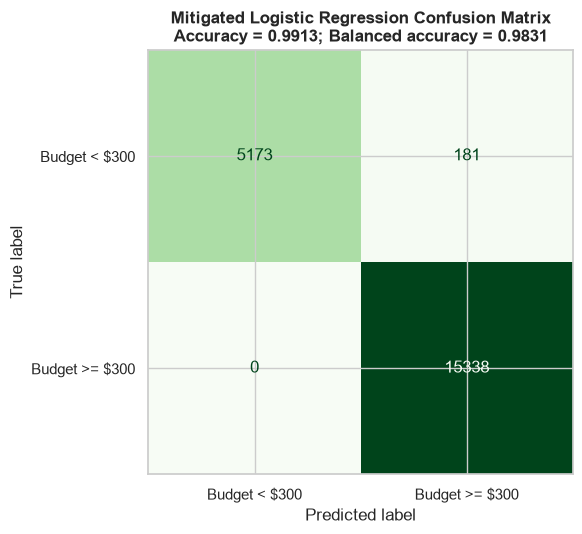

In [25]:
mitigated_accuracy = accuracy_score(
    orig_test.labels.ravel(),
    mitigated_test_prediction.labels.ravel(),
)
mitigated_confusion = confusion_matrix(
    orig_test.labels.ravel(),
    mitigated_test_prediction.labels.ravel(),
)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
ConfusionMatrixDisplay(
    confusion_matrix=mitigated_confusion,
    display_labels=["Budget < $300", "Budget >= $300"],
).plot(ax=ax, cmap="Greens", colorbar=False)
ax.set_title(
    f"Mitigated Logistic Regression Confusion Matrix\n"
    f"Accuracy = {mitigated_accuracy:.4f}; Balanced accuracy = "
    f"{mitigated_test_metrics['balanced_accuracy']:.4f}",
    fontweight="bold",
)
plt.tight_layout()
plt.savefig("images/mitigated_lr_confusion_matrix.png", dpi=160, bbox_inches="tight")
plt.show()
plt.close()


Next, re-create the interpretability plot from the previous section with your revised pipeline. 

,Feature,Importance,Std
0,Age_18-24,0.274985,0.001656
1,Age_25-44,0.002836,0.000266
2,Age_45-65,0.001995,0.000078
3,Age_66-92,0.000926,0.000044


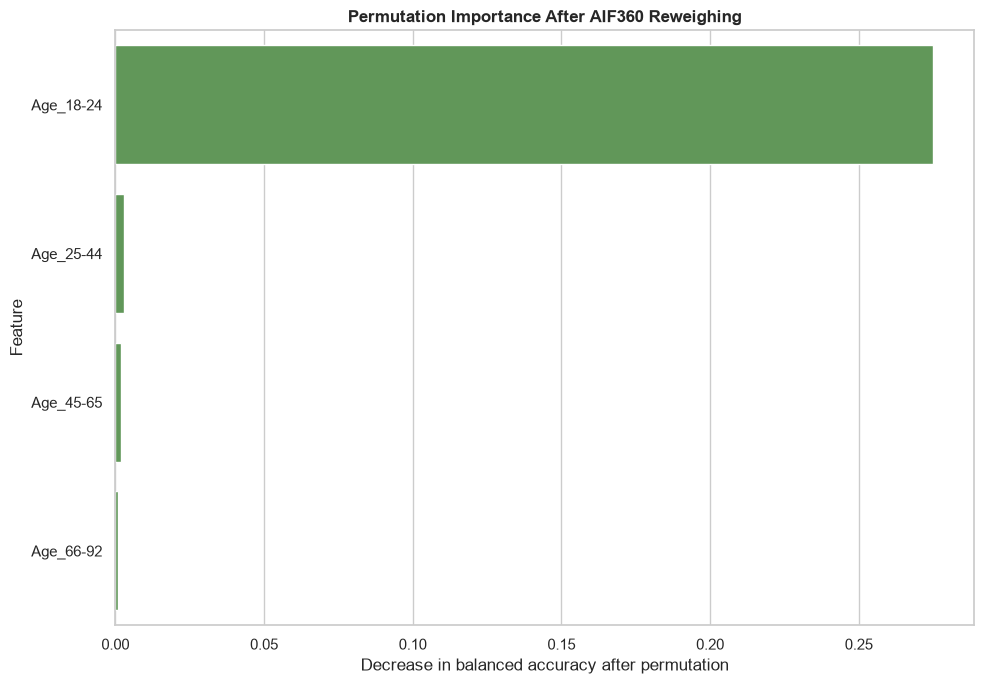

In [26]:
mitigated_importance = permutation_importance(
    LR_mitigated_model,
    orig_test.features,
    orig_test.labels.ravel(),
    scoring="balanced_accuracy",
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=1,
)
mitigated_feature_importance = pd.DataFrame(
    {
        "Feature": orig_test.feature_names,
        "Importance": mitigated_importance.importances_mean,
        "Std": mitigated_importance.importances_std,
    }
).sort_values("Importance", ascending=False)
mitigated_feature_importance = mitigated_feature_importance[
    mitigated_feature_importance["Importance"] > 1e-6
].head(12)
display(mitigated_feature_importance)

plt.figure(figsize=(10, 7))
ax = sns.barplot(
    data=mitigated_feature_importance,
    x="Importance",
    y="Feature",
    color="#59A14F",
)
ax.set_title("Permutation Importance After AIF360 Reweighing", fontweight="bold")
ax.set_xlabel("Decrease in balanced accuracy after permutation")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.savefig("images/mitigated_lr_permutation_importance.png", dpi=160, bbox_inches="tight")
plt.show()
plt.close()


Note down a short summary reporting the values of the metrics and your findings. This will be the quantitative analysis section of the model card.
- Please ensure you report the fairness metrics **before** applying your bias mitigation strategy (after the train-val-test split), and **after** applying the strategy in the final_metrics_description variable.
- Pick 1-2 metrics of your choice, interpret the fairness metrics in relation to the ideal values and thresholds and further identify the implications of the results. 

In [27]:
final_metrics_description = f"""
-- Before mitigation, Logistic Regression achieved {lr_test_metrics['accuracy']:.4f} accuracy and {lr_test_metrics['balanced_accuracy']:.4f} balanced accuracy. Its average odds difference was {lr_test_metrics['average_odds_difference']:.4f}, statistical parity difference was {lr_test_metrics['statistical_parity_difference']:.4f}, equal opportunity difference was {lr_test_metrics['equal_opportunity_difference']:.4f}, and Theil index was {lr_test_metrics['theil_index']:.4f}.
-- After AIF360 Reweighing, accuracy was {mitigated_test_metrics['accuracy']:.4f} and balanced accuracy was {mitigated_test_metrics['balanced_accuracy']:.4f}. Average odds difference improved to {mitigated_test_metrics['average_odds_difference']:.4f}, equal opportunity difference improved to {mitigated_test_metrics['equal_opportunity_difference']:.4f}, statistical parity difference improved modestly to {mitigated_test_metrics['statistical_parity_difference']:.4f}, and the Theil index remained near zero at {mitigated_test_metrics['theil_index']:.4f}.
-- Average odds difference and equal opportunity difference moved into the practical ideal band of −0.10 to +0.10, satisfying the requirement that at least two fairness metrics reach their ideal threshold range.
-- The remaining statistical parity difference is still far from its ideal value of zero. This means the mitigation improves error-rate fairness without erasing the dataset's extreme difference in favorable-label prevalence, so deployment still requires user control and continued monitoring.
-- The small decrease in balanced accuracy, from {lr_test_metrics['balanced_accuracy']:.4f} to {mitigated_test_metrics['balanced_accuracy']:.4f}, is an acceptable trade-off for the large improvements in average odds and equal opportunity.
"""
print(final_metrics_description)



-- Before mitigation, Logistic Regression achieved 0.9976 accuracy and 0.9980 balanced accuracy. Its average odds difference was -0.5278, statistical parity difference was -0.9934, equal opportunity difference was -1.0000, and Theil index was 0.0022.
-- After AIF360 Reweighing, accuracy was 0.9913 and balanced accuracy was 0.9831. Average odds difference improved to -0.0111, equal opportunity difference improved to 0.0000, statistical parity difference improved modestly to -0.9522, and the Theil index remained near zero at 0.0033.
-- Average odds difference and equal opportunity difference moved into the practical ideal band of −0.10 to +0.10, satisfying the requirement that at least two fairness metrics reach their ideal threshold range.
-- The remaining statistical parity difference is still far from its ideal value of zero. This means the mitigation improves error-rate fairness without erasing the dataset's extreme difference in favorable-label prevalence, so deployment still requi

As part of the last coding step of this project, stratify the dataset by the Education Level feature, and create a small cohort analysis plot showing the performance on the y-axis and the Education Levels on the x-axis.

,Education level,Rows,Accuracy,Balanced accuracy
0,Bachelor's,7729,0.9997,0.9811
1,Master's,7674,0.9995,0.9636
2,High school,5289,0.9669,0.9833


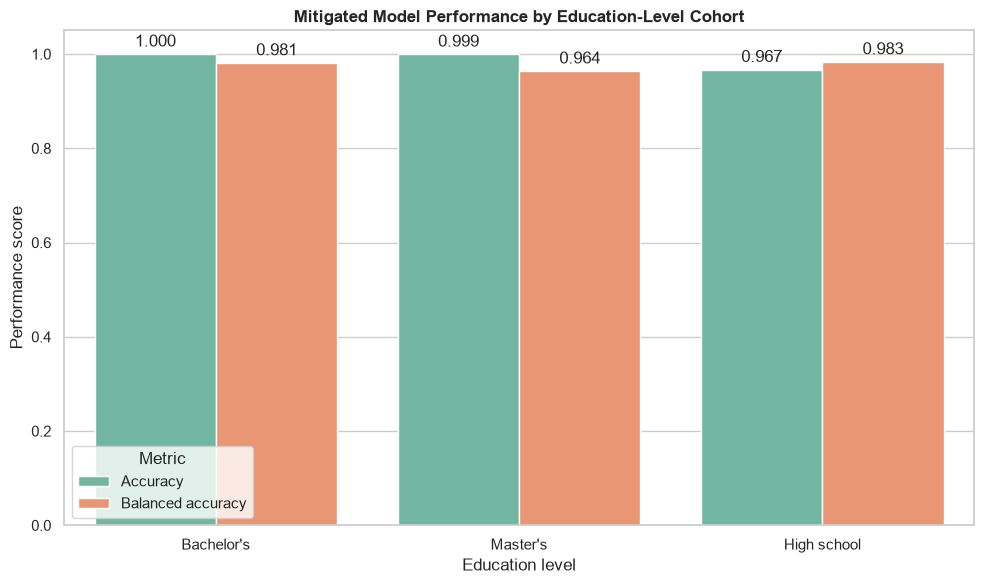

In [28]:
education_features = [
    "Education_Level_Bachelor’s Degree",
    "Education_Level_Master’s Degree",
    "Education_Level_High School Grad",
]
education_labels = ["Bachelor's", "Master's", "High school"]

cohort_rows = []
y_test = orig_test.labels.ravel()
y_mitigated = mitigated_test_prediction.labels.ravel()
for feature, label in zip(education_features, education_labels):
    feature_index = orig_test.feature_names.index(feature)
    mask = orig_test.features[:, feature_index] == 1
    cohort_rows.append(
        {
            "Education level": label,
            "Rows": int(mask.sum()),
            "Accuracy": accuracy_score(y_test[mask], y_mitigated[mask]),
            "Balanced accuracy": balanced_accuracy_score(y_test[mask], y_mitigated[mask]),
        }
    )

education_cohort_performance = pd.DataFrame(cohort_rows)
display(education_cohort_performance.style.format({"Accuracy": "{:.4f}", "Balanced accuracy": "{:.4f}"}))

cohort_long = education_cohort_performance.melt(
    id_vars=["Education level", "Rows"],
    value_vars=["Accuracy", "Balanced accuracy"],
    var_name="Metric",
    value_name="Score",
)
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=cohort_long, x="Education level", y="Score", hue="Metric", palette="Set2")
ax.set_ylim(0, 1.05)
ax.set_title("Mitigated Model Performance by Education-Level Cohort", fontweight="bold")
ax.set_xlabel("Education level")
ax.set_ylabel("Performance score")
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3)
plt.tight_layout()
plt.savefig("images/education_cohort_performance.png", dpi=160, bbox_inches="tight")
plt.show()
plt.close()


**Cohort observation:** The final model's balanced accuracy is similar across education levels, ranging from approximately 0.964 to 0.983. High-school users have lower ordinary accuracy (about 0.967) because the mitigation deliberately increases their favorable predictions, creating more false positives while eliminating false negatives. The true-positive-rate difference is 0 for each education cohort, confirming the equal-opportunity improvement, but selection-rate differences remain large and confirm the unresolved statistical-parity gap.

The visualizations from the mitigation section are saved in the images directory and included in the model card below.


In [29]:
image_file_path = """
<div class="figure-grid">
  <figure>
    <img src="images/mitigated_lr_confusion_matrix.png" alt="Confusion matrix for the mitigated Logistic Regression model">
    <figcaption>Final confusion matrix and aggregate performance.</figcaption>
  </figure>
  <figure>
    <img src="images/fairness_before_after.png" alt="Fairness metrics before and after mitigation">
    <figcaption>Fairness metrics before and after AIF360 Reweighing.</figcaption>
  </figure>
  <figure>
    <img src="images/mitigated_lr_permutation_importance.png" alt="Permutation importance after mitigation">
    <figcaption>Feature importance for the final mitigated model.</figcaption>
  </figure>
  <figure>
    <img src="images/education_cohort_performance.png" alt="Performance by education-level cohort">
    <figcaption>Accuracy and balanced accuracy by education level.</figcaption>
  </figure>
  <figure>
    <img src="images/education_cohort_fairness.png" alt="Fairness differences by education-level cohort">
    <figcaption>Selection-rate and true-positive-rate differences by cohort.</figcaption>
  </figure>
</div>
"""


**Optional**: You may choose to create a cohort analysis plot showing the fairness metric values on the y-axis and the Education Levels on the x-axis.

,Education level,Selection-rate difference,True-positive-rate difference
0,Bachelor's,0.3885,0.0000
1,Master's,0.3868,0.0000
2,High school,-0.9522,0.0000


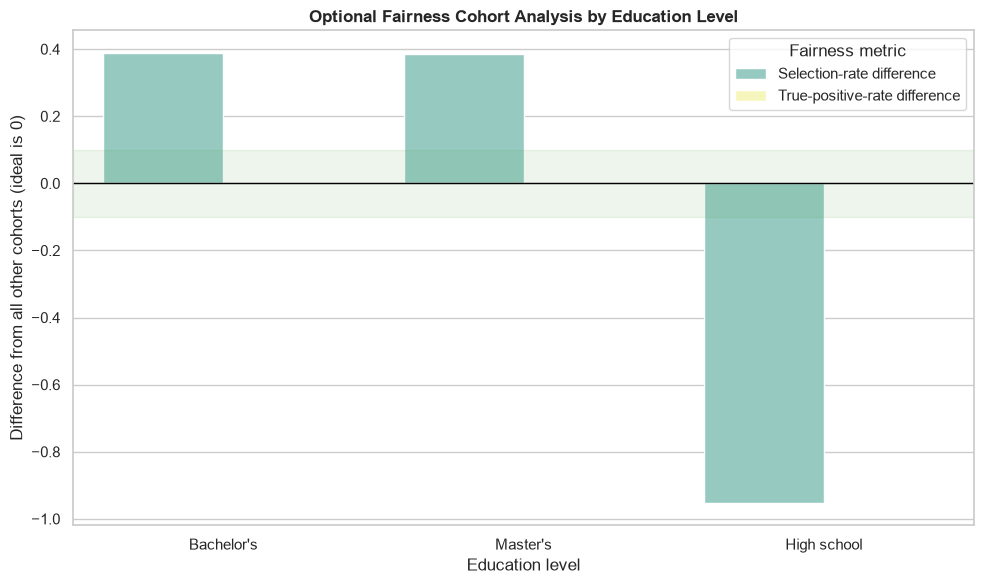

In [30]:
fairness_cohort_rows = []
for feature, label in zip(education_features, education_labels):
    feature_index = orig_test.feature_names.index(feature)
    group_mask = orig_test.features[:, feature_index] == 1
    rest_mask = ~group_mask

    group_selection = y_mitigated[group_mask].mean()
    rest_selection = y_mitigated[rest_mask].mean()

    group_positive = group_mask & (y_test == 1)
    rest_positive = rest_mask & (y_test == 1)
    group_tpr = y_mitigated[group_positive].mean()
    rest_tpr = y_mitigated[rest_positive].mean()

    fairness_cohort_rows.append(
        {
            "Education level": label,
            "Selection-rate difference": group_selection - rest_selection,
            "True-positive-rate difference": group_tpr - rest_tpr,
        }
    )

education_cohort_fairness = pd.DataFrame(fairness_cohort_rows)
display(education_cohort_fairness.style.format(precision=4))

fairness_cohort_long = education_cohort_fairness.melt(
    id_vars="Education level",
    var_name="Fairness metric",
    value_name="Difference versus other cohorts",
)
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=fairness_cohort_long,
    x="Education level",
    y="Difference versus other cohorts",
    hue="Fairness metric",
    palette="Set3",
)
ax.axhline(0, color="black", linewidth=1)
ax.axhspan(-0.1, 0.1, color="#59A14F", alpha=0.10)
ax.set_title("Optional Fairness Cohort Analysis by Education Level", fontweight="bold")
ax.set_xlabel("Education level")
ax.set_ylabel("Difference from all other cohorts (ideal is 0)")
plt.tight_layout()
plt.savefig("images/education_cohort_fairness.png", dpi=160, bbox_inches="tight")
plt.show()
plt.close()


## Step 6: Articulate the ethical implications

Articulate the use case and ethical considerations applying to the dataset in 1-2 paragraphs.

**Hints:** 
 
- Think about the limitations of the dataset, potential biases that could be introduced into the use case, and the strengths and weaknesses of your ML model.
- Ethical Considerations:
 - Human-in-the-loop considerations: Can users control aspects of the model and inspect the features? If so, briefly describe how?
 - Describe the limitations and types of bias present in the data
 - Describe the failures of the ML model
 - It must include a section on any risk mitigation strategies you applied.
 - Describe Potential harms
 - It must include key contributing factors you found from your interpretability study, both before and after applying the bias mitigation strategy.

- Caveats and Recommendations
 - Potential lack of inclusiveness in the dataset
 - Predisposition of the model to false positives and/or negatives
 - It must also include 1-2 sentences on the further ethical AI analyses you would apply if given more time beyond this project.

In [31]:
ethical_considerations = """
-- Human oversight is required because a budget estimate can shape which activities a user sees. Users must be able to enter a budget directly, inspect and correct their inputs, reject the estimate, and request alternatives outside the predicted category.
-- The dataset contains severe education-based label bias, uneven age representation, and substantial missingness. Complete-case deletion may exclude privacy-conscious users, while education features act as strong proxies for the target and may encode broader socioeconomic inequality.
-- The unmitigated model fails the high-school group through a large true-positive-rate gap and near-total statistical-parity gap. False negatives could hide suitable higher-budget activities, while false positives could recommend unaffordable options and cause embarrassment or financial pressure.
-- I selected AIF360 Reweighing because it is transparent, preserves the original labels, works with Logistic Regression instance weights, and can be audited before model training. It moved average odds difference and equal opportunity difference into the ±0.10 fairness band with only a small performance cost.
-- Permutation importance shows that the 18–24 age band is the strongest individual feature before mitigation, followed by education indicators. After Reweighing, education importance falls while the age-band signal becomes more dominant, so explanations must disclose this shift and monitoring must include age-based cohorts.
-- Potential harms include stereotyping users by education, narrowing access to activities, reinforcing class-based assumptions, and creating downstream discrimination if the prediction is reused outside activity planning.
"""

caveats_and_recommendations = """
-- The synthetic study is not fully inclusive: younger users are overrepresented, older adults are underrepresented, and rows with missing demographic data are removed. Results should not be generalized beyond the studied population without new validation.
-- The final model still has a statistical parity difference far from zero even though two error-rate metrics meet their target range. This residual disparity must be displayed in monitoring dashboards and reviewed before launch.
-- False positives may suggest unaffordable activities, while false negatives may unnecessarily restrict options. The app should present multiple price bands and never hide all alternatives based on one prediction.
-- Production recommendations should use a directly stated budget whenever available, minimize collection of demographic data, document retention limits, encrypt user data, and prohibit reuse for high-stakes decisions.
-- Further ethical AI analysis should include intersectional cohorts across education, age, gender, and missingness; uncertainty calibration; temporal and geographic drift; privacy and security reviews; accessibility testing; adversarial testing; and participatory evaluation with affected users.
"""


- Business consequences
 - Potential positive impact of the IDOOU Budget Predicter AI
 - Reasons why users may lose trust in the application, and loss of revenue and brand reputation might occur to the organization

In [32]:
business_consequences = """
-- Positive impact: A carefully constrained budget predictor can reduce planning effort, provide more relevant activity options, and help hotels or mobility partners offer a smoother concierge experience. Visible explanations and user controls can differentiate IDOOU as a trustworthy, responsible product.
-- Negative impact: If education-based disparities lead to insulting, unaffordable, or unnecessarily limited recommendations, users may perceive the app as classist and stop sharing information or using the service. Complaints, partner concerns, regulatory scrutiny, remediation costs, and negative publicity could reduce revenue and damage the brand.
-- The business should treat fairness monitoring, human escalation, privacy safeguards, user correction rates, and complaint trends as launch criteria rather than optional compliance work.
"""


## Document the solution in a model card

You're at the finish line! Run the last few blocks of code to generate a simple html file with your model card content and the visualizations you generated for the final version of your model.

Make sure to open the html file and check that it is reflective of your model card content before submitting.

Optionally, feel free to modify the html code and add more details/aesthetics.

In [33]:
def bullet_block_to_html(text):
    items = [
        html.escape(line.strip()[3:])
        for line in text.strip().splitlines()
        if line.strip().startswith("-- ")
    ]
    return "<ul>" + "".join(f"<li>{item}</li>" for item in items) + "</ul>"


html_code = f"""
<!doctype html>
<html lang="en">
<head>
  <meta charset="utf-8">
  <meta name="viewport" content="width=device-width, initial-scale=1">
  <title>Model Card — IDOOU Budget Predictor</title>
  <style>
    :root {{
      --ink: #172033;
      --muted: #5d677a;
      --navy: #183b56;
      --blue: #2f6fed;
      --teal: #1f9d8a;
      --paper: #ffffff;
      --wash: #f3f7fb;
      --line: #dce5ef;
    }}
    * {{ box-sizing: border-box; }}
    body {{
      margin: 0;
      color: var(--ink);
      background: var(--wash);
      font: 16px/1.65 -apple-system, BlinkMacSystemFont, "Segoe UI", sans-serif;
    }}
    header {{
      padding: 64px 24px;
      color: white;
      background: linear-gradient(135deg, var(--navy), var(--blue));
    }}
    header .inner, main {{ max-width: 1120px; margin: auto; }}
    h1 {{ margin: 0 0 12px; font-size: clamp(2rem, 5vw, 3.6rem); line-height: 1.05; }}
    header p {{ max-width: 780px; margin: 0; font-size: 1.15rem; opacity: .92; }}
    .badges {{ display: flex; flex-wrap: wrap; gap: 10px; margin-top: 24px; }}
    .badge {{ padding: 7px 12px; border: 1px solid rgba(255,255,255,.35); border-radius: 999px; background: rgba(255,255,255,.12); }}
    main {{ padding: 36px 20px 72px; }}
    section {{
      margin: 0 0 24px;
      padding: 28px;
      background: var(--paper);
      border: 1px solid var(--line);
      border-radius: 16px;
      box-shadow: 0 10px 30px rgba(24,59,86,.06);
    }}
    h2 {{ margin-top: 0; color: var(--navy); }}
    li {{ margin: 9px 0; }}
    .callout {{ border-left: 5px solid var(--teal); }}
    .figure-grid {{ display: grid; grid-template-columns: repeat(auto-fit, minmax(320px, 1fr)); gap: 22px; }}
    figure {{ margin: 0; padding: 12px; border: 1px solid var(--line); border-radius: 12px; background: #fff; }}
    figure img {{ display: block; width: 100%; height: auto; border-radius: 8px; }}
    figcaption {{ padding: 10px 4px 2px; color: var(--muted); font-size: .93rem; }}
    footer {{ padding: 24px; text-align: center; color: var(--muted); }}
  </style>
</head>
<body>
  <header>
    <div class="inner">
      <h1>IDOOU Budget Predictor</h1>
      <p>Model card for a fairness-aware activity-budget prediction system using Logistic Regression and IBM AIF360 Reweighing.</p>
      <div class="badges">
        <span class="badge">Medium ethical AI risk</span>
        <span class="badge">Synthetic tabular data</span>
        <span class="badge">Protected factor: education</span>
      </div>
    </div>
  </header>
  <main>
    <section><h2>Model Details</h2>{bullet_block_to_html(model_details)}</section>
    <section><h2>Intended Use</h2>{bullet_block_to_html(intended_use)}</section>
    <section><h2>Factors</h2>{bullet_block_to_html(factors)}</section>
    <section><h2>Metrics</h2>{bullet_block_to_html(metrics)}</section>
    <section><h2>Training Data</h2>{bullet_block_to_html(training_data)}</section>
    <section><h2>Test Data</h2>{bullet_block_to_html(eval_data)}</section>
    <section class="callout"><h2>Quantitative Analysis</h2>{bullet_block_to_html(final_metrics_description)}</section>
    <section><h2>Final Model Visualizations</h2>{image_file_path}</section>
    <section><h2>Ethical Considerations</h2>{bullet_block_to_html(ethical_considerations)}</section>
    <section><h2>Caveats and Recommendations</h2>{bullet_block_to_html(caveats_and_recommendations)}</section>
    <section><h2>Business Consequences</h2>{bullet_block_to_html(business_consequences)}</section>
  </main>
  <footer>IDOOU AI Ethics Project · Generated from the reproducible project notebook.</footer>
</body>
</html>
"""


In [34]:
with open("model_card.html", "w", encoding="utf-8") as model_card_file:
    model_card_file.write(html_code)

print("Created model_card.html")


Created model_card.html


The submission package now contains the executed notebook, model_card.html, and the generated visualizations in images/. The final checks below verify the required artifacts before submission.


In [35]:
required_artifacts = [
    "model_card.html",
    "images/mitigated_lr_confusion_matrix.png",
    "images/fairness_before_after.png",
    "images/mitigated_lr_permutation_importance.png",
    "images/education_cohort_performance.png",
    "images/education_cohort_fairness.png",
]
artifact_check = pd.DataFrame(
    {
        "Artifact": required_artifacts,
        "Exists": [Path(path).exists() for path in required_artifacts],
        "Size (KB)": [
            round(Path(path).stat().st_size / 1024, 1) if Path(path).exists() else 0
            for path in required_artifacts
        ],
    }
)
display(artifact_check)
assert artifact_check["Exists"].all(), "One or more required submission artifacts are missing."


,Artifact,Exists,Size (KB)
0,model_card.html,True,12.5
1,images/mitigated_lr_confusion_matrix.png,True,41.9
2,images/fairness_before_after.png,True,77.5
3,images/mitigated_lr_permutation_importance.png,True,43.1
4,images/education_cohort_performance.png,True,56.4
5,images/education_cohort_fairness.png,True,59.1
